# Volatility breakout trading strategy for EUR/PLN with GARCH-based volatility forecasting
### Zofia Broszczak - index number: 446277

### Importing packages and setting the working directory

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

import os
import locale

import statsmodels.api as sm

from arch import arch_model

In [2]:
locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')
os.chdir("C:\\Users\\zosia\\OneDrive\\Dokumenty\\DS&BA\\SEM3\\Applied Finance\\project1")

## Reading the data
I obtained the historical EUR/PLN tick data for the period: 01.09.2025, 12:00 AM – 06.10.2025, 12:00 AM using the dukascopy-node data downloader. I specified the instrument, date range, and data type directly in the terminal so that the tool queried the Dukascopy historical data servers and exported all available tick-level records for the period descibed in the project requirement file. The result was a csv file containing bid/ask quotes with timestamps.

In [3]:
data = pd.read_csv("eurpln-tick-2025-09-01-2025-10-06.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595907 entries, 0 to 595906
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   timestamp  595907 non-null  int64  
 1   askPrice   595907 non-null  float64
 2   bidPrice   595907 non-null  float64
 3   askVolume  595907 non-null  float64
 4   bidVolume  595907 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 22.7 MB


In [4]:
data.head()

,timestamp,askPrice,bidPrice,askVolume,bidVolume
0,1756684800051,4.26339,4.25996,0.9,0.90
1,1756684800102,4.26338,4.26125,0.9,0.90
2,1756684800152,4.26339,4.26100,0.9,0.12
3,1756684800204,4.26338,4.26094,0.9,0.12
4,1756684800561,4.26323,4.26093,0.9,0.12


### Transforming the timestamp column into datetime format and chnaging the timezone to Europe-Warsaw.

In [5]:
data["Local time"] = pd.to_datetime(data["timestamp"], unit="ms", utc=True)
data.head()

,timestamp,askPrice,bidPrice,askVolume,bidVolume,Local time
0,1756684800051,4.26339,4.25996,0.9,0.90,2025-09-01 00:00:00.051000+00:00
1,1756684800102,4.26338,4.26125,0.9,0.90,2025-09-01 00:00:00.102000+00:00
2,1756684800152,4.26339,4.26100,0.9,0.12,2025-09-01 00:00:00.152000+00:00
3,1756684800204,4.26338,4.26094,0.9,0.12,2025-09-01 00:00:00.204000+00:00
4,1756684800561,4.26323,4.26093,0.9,0.12,2025-09-01 00:00:00.561000+00:00


In [6]:
data.tail(5)

,timestamp,askPrice,bidPrice,askVolume,bidVolume,Local time
595902,1759708275938,4.25548,4.25268,1.8,0.9,2025-10-05 23:51:15.938000+00:00
595903,1759708290495,4.25547,4.25268,0.9,0.9,2025-10-05 23:51:30.495000+00:00
595904,1759708344289,4.25547,4.25269,0.9,0.9,2025-10-05 23:52:24.289000+00:00
595905,1759708471434,4.25546,4.25269,0.9,0.9,2025-10-05 23:54:31.434000+00:00
595906,1759708551426,4.25544,4.25269,0.9,0.9,2025-10-05 23:55:51.426000+00:00


In [7]:
data["Local time"] = data["Local time"].dt.tz_convert("Europe/Warsaw") # converting to Europe/Warsaw timezone
data.set_index("Local time", inplace=True) # converting the dataset to a dataframe with "Local time" as the index
data.drop(columns=["timestamp"], inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 595907 entries, 2025-09-01 02:00:00.051000+02:00 to 2025-10-06 01:55:51.426000+02:00
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   askPrice   595907 non-null  float64
 1   bidPrice   595907 non-null  float64
 2   askVolume  595907 non-null  float64
 3   bidVolume  595907 non-null  float64
dtypes: float64(4)
memory usage: 22.7 MB


In [9]:
data.head()

,askPrice,bidPrice,askVolume,bidVolume
Local time,,,,
2025-09-01 02:00:00.051000+02:00,4.26339,4.25996,0.9,0.90
2025-09-01 02:00:00.102000+02:00,4.26338,4.26125,0.9,0.90
2025-09-01 02:00:00.152000+02:00,4.26339,4.26100,0.9,0.12
2025-09-01 02:00:00.204000+02:00,4.26338,4.26094,0.9,0.12
2025-09-01 02:00:00.561000+02:00,4.26323,4.26093,0.9,0.12


In [10]:
print(data.index)

DatetimeIndex(['2025-09-01 02:00:00.051000+02:00',
               '2025-09-01 02:00:00.102000+02:00',
               '2025-09-01 02:00:00.152000+02:00',
               '2025-09-01 02:00:00.204000+02:00',
               '2025-09-01 02:00:00.561000+02:00',
               '2025-09-01 02:00:00.612000+02:00',
               '2025-09-01 02:00:00.662000+02:00',
               '2025-09-01 02:00:01.164000+02:00',
               '2025-09-01 02:00:01.265000+02:00',
               '2025-09-01 02:00:01.466000+02:00',
               ...
               '2025-10-06 01:50:18.070000+02:00',
               '2025-10-06 01:50:19.878000+02:00',
               '2025-10-06 01:50:39.201000+02:00',
               '2025-10-06 01:50:41.259000+02:00',
               '2025-10-06 01:51:15.888000+02:00',
               '2025-10-06 01:51:15.938000+02:00',
               '2025-10-06 01:51:30.495000+02:00',
               '2025-10-06 01:52:24.289000+02:00',
               '2025-10-06 01:54:31.434000+02:00',
            

In [11]:
data.memory_usage(deep=True)

Index        4767256
askPrice     4767256
bidPrice     4767256
askVolume    4767256
bidVolume    4767256
dtype: int64

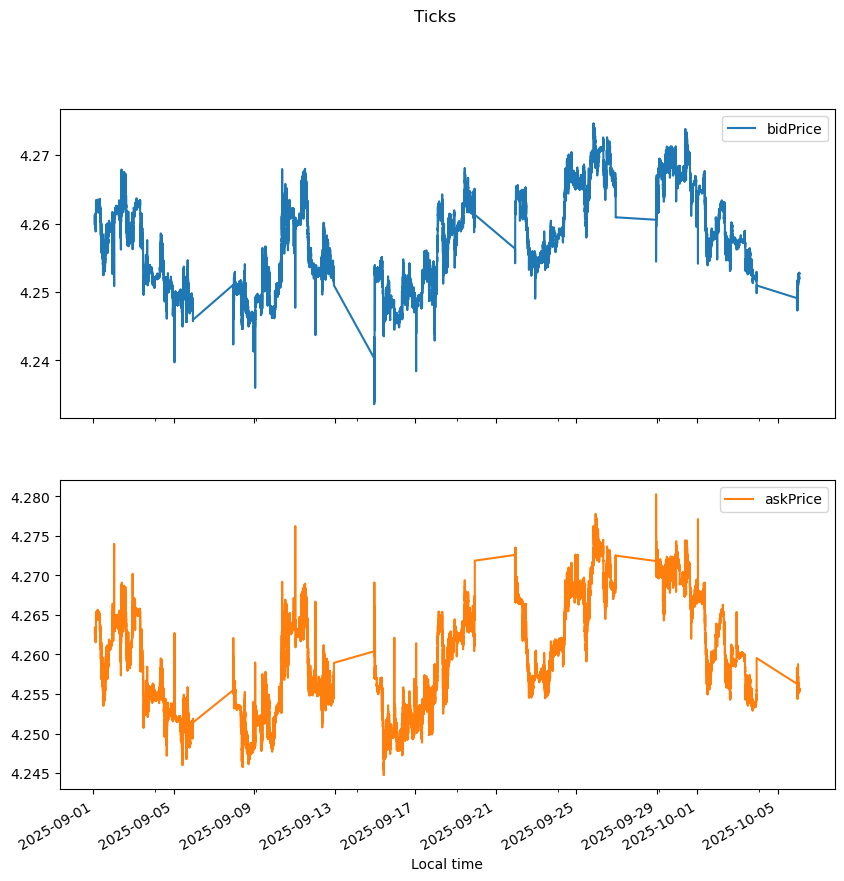

In [12]:
# plotting the data
data[['bidPrice', 'askPrice']].plot(subplots=True, layout=(2, 1), title="Ticks", figsize=(10, 10))
plt.show()

# Aggregating to 5-minute bars
I convert the raw tick-level EUR/PLN quotes into a regular 5-minute time series by taking the last bid/ask quote in each interval. 

I handled short gaps with no ticks using a limited forward-fill (up to 15 minutes). 

I then keep only active trading hours (weekdays, 07:00–20:00 Europe/Warsaw), drop any remaining missing values.

In [13]:
# aggregation to 5-min data + forward filling of missing values
data_5min = (
    data
    .resample('5min', label='right', closed='right')
    .agg({'bidPrice':'last','askPrice':'last'})
    .ffill(limit=3)
)

# keeping only active trading hours - Mon–Fri & 07:00–20:00 Europe/Warsaw
is_weekday = data_5min.index.dayofweek < 5
is_hours   = (data_5min.index.hour >= 7) & (data_5min.index.hour < 20)
data_5min  = data_5min.loc[is_weekday & is_hours]

# dropping any bars still missing quotes
data_5min  = data_5min.dropna(subset=['bidPrice','askPrice'])

data_5min.head()

,bidPrice,askPrice
Local time,,
2025-09-01 07:00:00+02:00,4.26307,4.26483
2025-09-01 07:05:00+02:00,4.26304,4.26458
2025-09-01 07:10:00+02:00,4.26316,4.26468
2025-09-01 07:15:00+02:00,4.26324,4.26467
2025-09-01 07:20:00+02:00,4.26320,4.26469


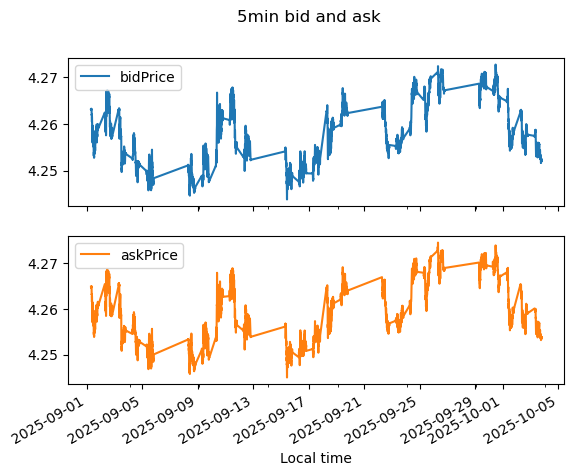

In [14]:
# plotting 5-min close prices
data_5min[['bidPrice', 'askPrice']].plot(title="5min bid and ask", subplots=True, layout=(2, 1))
plt.show()

In [15]:
print(f"we have {data_5min.shape[0]} observations.")

we have 3900 observations.


### Splitting the data into in-sample and out-of-sample subsets
I split 5-minute data into in-sample (for parameter selection) and out-of-sample (for performance evaluation) as per the project requirements.

In [17]:
oos_start = pd.Timestamp('2025-09-22 00:00:00', tz='Europe/Warsaw')
oos_end   = pd.Timestamp('2025-10-06 00:00:00', tz='Europe/Warsaw')

out_of_sample = data_5min.loc[(data_5min.index >= oos_start) & (data_5min.index < oos_end)].copy()

in_sample = data_5min.loc[data_5min.index < oos_start].copy()

### Visualisation of bid/ask price behaviour

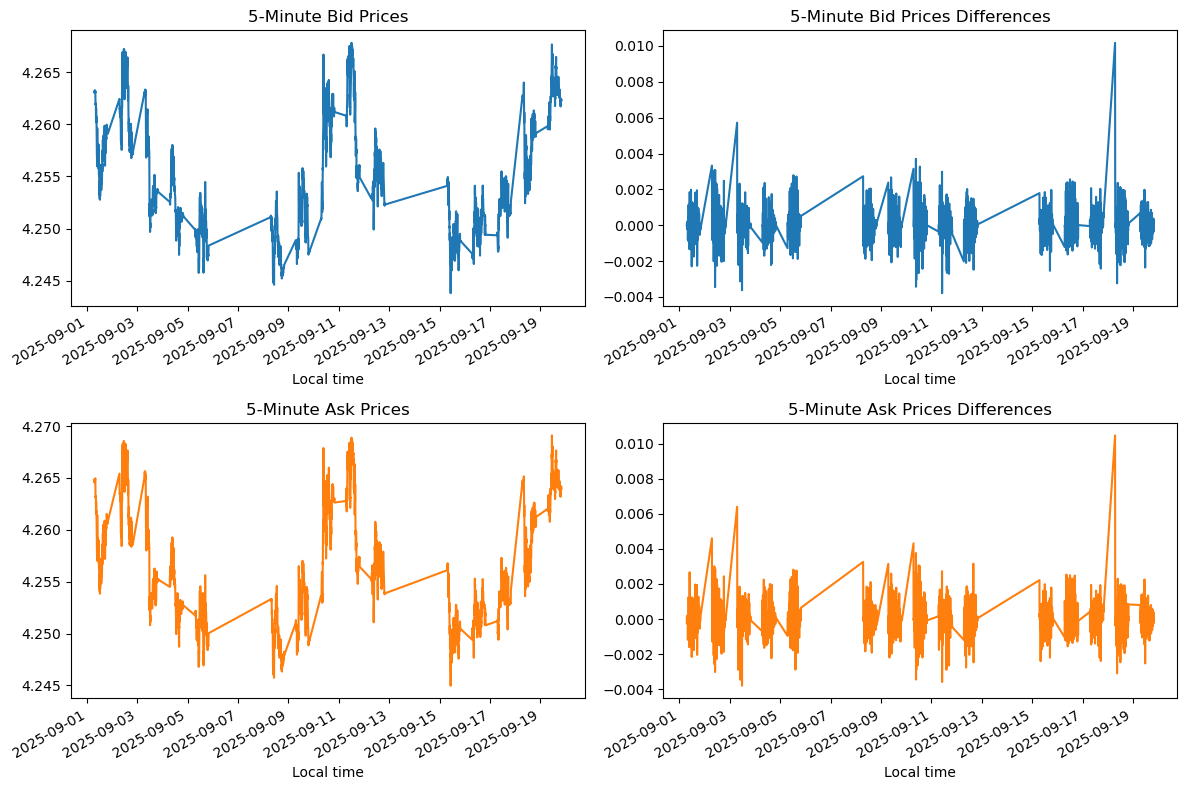

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color'] 

color_map = {
    'bidPrice': colors[0],
    'askPrice': colors[1]
}

# In the left column, I plot the raw 5-minute series
in_sample['bidPrice'].plot(ax=axes[0,0], color=color_map['bidPrice'], title='5-Minute Bid Prices')
in_sample['askPrice'].plot(ax=axes[1,0], color=color_map['askPrice'], title='5-Minute Ask Prices')

# In the right column, I plot the differences
in_sample['bidPrice'].diff().plot(ax=axes[0,1], color=color_map['bidPrice'], title='5-Minute Bid Prices Differences')
in_sample['askPrice'].diff().plot(ax=axes[1,1], color=color_map['askPrice'], title='5-Minute Ask Prices Differences')

plt.tight_layout()
plt.show()


The figures show the 5-minute bid and ask prices and their first differences. As expected, 5-Minute Bid and Ask Prices exhibit clear non-stationary behaviour, while the differences look more stationary.

### Additional stationarity and cointegration checks

As an additional diagnostic step at the beginning of the project, toget familiar with the data anc confirm that it behaves as expected, I examined the stationarity of the 5-minute bid and ask prices and tested for cointegration between them. 

As expected for FX data, both series were non-stationary in levels, stationary in first differences, and cointegrated. 

This is not directly relevant for the volatility breakout or GARCH modelling that I use later on, therefore I ommited the code for these tests and decided to present the findings of the analysis this way.

## Volatility breakout model based on GARCH
For my model choice, I combined a standard volatility breakout idea with GARCH-driven volatility estimates to make the model more responsive to real intraday behaviour. The trading signals come from fast and slow rolling means, while the GARCH model updates the width of the breakout bands so they expand during volatile periods and contract when markets are calm. This lets the strategy adapt to changing market regimes rather than relying on fixed thresholds.

Notional setup and annualization constants

In [19]:
LOT_EUR = 100_000 # 1 standard FX lot = 100k EUR
contract_value = LOT_EUR # P&L in PLN (price is PLN per EUR)

BARS_PER_DAY   = 13 * 12 # 07:00–20:00 Warsaw = 13h*12 bars/h = 156
DAYS_PER_YEAR  = 252
BARS_PER_YEAR  = BARS_PER_DAY * DAYS_PER_YEAR

def mySR(x, scale=BARS_PER_YEAR):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)


### Rolling GARCH(1,1) volatility forecasting on 5-minute returns

I compute 5-minute log returns from the mid-price. To get a forward-looking meassure of market volatility, I estimate a rolling GARCH(1,1) model on the 5-minute log returns using an expanding window. At each step, the model produces a 1-step-ahead forcast of return volatility.

Then, I scale this predicted return volatility by the lagged-mid-price to make it in price units to be able to compare it to the market level. This price based volatility then determines the width of the breakout bands in the trading strategy.

At 5-minute frequency on EURPLN, the conditional mean is very close to zero, so I estimate a zero-mean GARCH(1,1) and use only the conditional volatility forecast as an input to the breakout bands.


In [20]:
mid_train = in_sample.eval('(bidPrice + askPrice)/2')
mid_test  = out_of_sample.eval('(bidPrice + askPrice)/2')

In [21]:
mid_full = data_5min.eval("(bidPrice + askPrice)/2")
mid_full.name = "mid"

ret_full = np.log(mid_full).diff().dropna()
ret_full.name = "ret_5m"

sigma_ret = pd.Series(index=ret_full.index, dtype="float64")

refit_freq = 100
min_obs    = 50
res = None

for t, ts in enumerate(ret_full.index):
    r_window = ret_full.iloc[:t+1]

    if len(r_window) < min_obs:
        continue

    if (t % refit_freq == 0) or (res is None):
        am = arch_model(
            r_window,
            vol="GARCH",
            p=1,
            q=1,
            mean="Zero",
            rescale=False
        )
        res = am.fit(disp="off")

    fcast = res.forecast(horizon=1, reindex=False)
    sigma_ret.iloc[t] = np.sqrt(fcast.variance.iloc[-1, 0])

sigma_ret = sigma_ret.ffill()

sigma_price_full = pd.Series(index=mid_full.index, dtype="float64")
sigma_price_full.loc[sigma_ret.index] = mid_full.loc[sigma_ret.index].shift(1) * sigma_ret
sigma_price_full = sigma_price_full.ffill().bfill()
sigma_price_full.name = "sigma_price"

sigma_price_train = sigma_price_full.loc[in_sample.index]
sigma_price_test  = sigma_price_full.loc[out_of_sample.index]

print("GARCH sigma train NaN share:", sigma_price_train.isna().mean())
print("GARCH sigma test  NaN share:", sigma_price_test.isna().mean())


C:\Users\zosia\AppData\Local\Temp\ipykernel_15048\4256866944.py:28: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")
C:\Users\zosia\AppData\Local\Temp\ipykernel_15048\4256866944.py:28: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")
C:\Users\zosia\AppData\Local\Temp\ipykernel_15048\4256866944.py:28: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")
C:\Users\zosia\AppData\Local\Temp\ipykernel_15048\4256866944.py:28: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")
C:\Users\zos

GARCH sigma train NaN share: 0.0
GARCH sigma test  NaN share: 0.0


### Position-blocking filter (market hours + spread outlier filter)
I created a position-blocking mask to ensure the strategy trades only under normal market conditions. I allow trading only on weekdays between 07:00 and 20:00 Warsaw time, and I also block trading when the big-ask spread exceeds the 99th percentile of its in-sample distribution.

In [22]:
def build_pos_flat_index(idx, series_for_threshold, thr_q=0.99, use_time_filters=True):
    pos_flat = np.zeros(len(idx), dtype=int)

    if use_time_filters:
        pos_flat[idx.dayofweek >= 5] = 1
        pos_flat[(idx.hour < 7) | (idx.hour >= 20)] = 1

    thr = series_for_threshold.quantile(thr_q)
    series_aligned = series_for_threshold.reindex(idx, method='nearest', tolerance='30min')
    pos_flat[series_aligned > thr] = 1
    return pos_flat

spread_train = in_sample['askPrice'] - in_sample['bidPrice']
spread_test  = out_of_sample['askPrice'] - out_of_sample['bidPrice']

pos_flat_train = build_pos_flat_index(
    in_sample.index,
    series_for_threshold=spread_train,
    thr_q=0.99,
    use_time_filters=True
)

pos_flat_test = build_pos_flat_index(
    out_of_sample.index,
    series_for_threshold=spread_train,
    thr_q=0.99,
    use_time_filters=True
)

### Position function

Then I used the position function which turns signals into actual trading positions. It enters long or short on valid breakouts and otherwise keeps the previous position.

In [23]:
def position(signal, lower, upper, pos_flat, strategy):
    position = np.zeros(len(signal))
    lo_scalar = np.isscalar(lower); up_scalar = np.isscalar(upper)
    for i in range(1, len(signal)):
        if pos_flat[i] == 1:
            position[i] = 0; continue
        s  = signal.iloc[i-1]
        lo = lower if lo_scalar else lower.iloc[i-1]
        up = upper if up_scalar  else upper.iloc[i-1]
        if np.isnan(s) or np.isnan(lo) or np.isnan(up):
            position[i] = position[i-1]; continue
        # momentum strategy
        if position[i-1] == 0:
            position[i] =  1 if s > up else (-1 if s < lo else 0)
        elif position[i-1] == 1:
            position[i] =  1 if s > lo else -1
        else:
            position[i] = -1 if s < up else  1
    # mean-reversion strategy
    if strategy == "mr":
        position = -position
    return position


### Parameter search for the model

To choose the best version of the volatility-breakout model, I ran a grid search over many parameter combinations. I varied the band-width multiplier k, the fast and slow EWMA windows, the volatility smoothing window, and the choice between momentum and mean-reversion logic. All models used the same GARCH-based volatility bands.

In [24]:
results = []

contract_value = LOT_EUR

for k in [1, 2, 3]:
    for signal_span in [15, 30, 45]:
        for slower_span in [60, 90, 120]:
            for sd_span in [30, 60, 90]:
                for strategy in ["mom", "mr"]:

                    signal = mid_train.ewm(span=signal_span).mean()
                    base   = mid_train.ewm(span=slower_span).mean()
                    sigma  = sigma_price_train.rolling(window=sd_span).mean()  # GARCH-based price volatility
                    lower  = base - k * sigma
                    upper  = base + k * sigma

                    pos = position(
                        signal=signal,
                        lower=lower,
                        upper=upper,
                        pos_flat=pos_flat_train,
                        strategy=strategy
                    )

                    dmid = mid_train.diff().fillna(0)
                    pnl_gross = pos * dmid * contract_value

                    switches = np.where(np.abs(np.diff(pos, prepend=0)) > 0)[0]
                    tx_costs = (
                        in_sample['askPrice'].iloc[switches] -
                        in_sample['bidPrice'].iloc[switches]
                    ) * contract_value

                    pnl_net_total = pnl_gross.sum() - tx_costs.sum()

                    pnl_net_series = pnl_gross.copy()
                    if len(switches):
                        pnl_net_series.iloc[switches] -= (
                            in_sample['askPrice'].iloc[switches] -
                            in_sample['bidPrice'].iloc[switches]
                        ) * contract_value

                    sr_gross = mySR(pnl_gross)
                    sr_net   = mySR(pnl_net_series)


                    results.append([
                        k, signal_span, slower_span, sd_span, strategy,
                        np.round(pnl_gross.sum(), 2),
                        np.round(sr_gross, 2),
                        int((np.abs(np.diff(pos, prepend=0))).sum()),
                        np.round(pnl_net_total, 2),
                        np.round(sr_net, 2)
                    ])

# results table
results_df = pd.DataFrame(
    results,
    columns=['k', 'signal_span', 'slower_span', 'sd_span', 'strategy',
             'pnl_gross', 'sr_gross', 'ntrans', 'pnl_net', 'sr_net']
)

display(results_df.sort_values('pnl_net', ascending=False).head())
display(results_df.sort_values('sr_net',  ascending=False).head())

C:\Users\zosia\AppData\Local\Temp\ipykernel_15048\3904207973.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)


,k,signal_span,slower_span,sd_span,strategy,pnl_gross,sr_gross,ntrans,pnl_net,sr_net
9,1,15,90,60,mr,9803.5,10.19,67,1811.5,1.79
7,1,15,90,30,mr,9494.5,9.80,67,1541.5,1.51
11,1,15,90,90,mr,9389.0,9.80,67,1410.0,1.40
3,1,15,60,60,mr,9587.0,10.00,71,1251.0,1.23
1,1,15,60,30,mr,9267.5,9.57,71,925.5,0.90


,k,signal_span,slower_span,sd_span,strategy,pnl_gross,sr_gross,ntrans,pnl_net,sr_net
9,1,15,90,60,mr,9803.5,10.19,67,1811.5,1.79
7,1,15,90,30,mr,9494.5,9.80,67,1541.5,1.51
11,1,15,90,90,mr,9389.0,9.80,67,1410.0,1.40
3,1,15,60,60,mr,9587.0,10.00,71,1251.0,1.23
1,1,15,60,30,mr,9267.5,9.57,71,925.5,0.90


### Best parameter combination on the training sample by P&L

In [25]:
best = results_df.sort_values('pnl_net', ascending=False).iloc[0]
k_best, sspan, lspan, sdspan, strat = best[['k','signal_span','slower_span','sd_span','strategy']]

print("Chosen (TRAIN) params:",
      f"k={k_best}, signal_span={sspan}, slower_span={lspan}, sd_span={sdspan}, strategy={strat}")


Chosen (TRAIN) params: k=1, signal_span=15, slower_span=90, sd_span=60, strategy=mr


After evaluating all combinations on the tarining set, the best results were:
- k = 1
- signal_span = 15
- slower_span - 90
- sd_span = 60
- strategy = mr

So, the strategy performs best when the bands are quite tight, the signal reacts quickly, the base moves slowly, the volatility is smoothed moderately, and the strategy is mean-reversion rather than momentum.

### Out-of-sample evaluation using best training parameters
I then applied the best parameter combination identified on the training sample to the out-of-sample data and calculated gross and net P&L, and gross and net Sharpe ratios to evaluate my strategy.

In [26]:
signal_te = mid_test.ewm(span=sspan).mean()
base_te   = mid_test.ewm(span=lspan).mean()
sigma_te  = sigma_price_test.rolling(sdspan).mean() 
lower_te  = base_te - k_best * sigma_te
upper_te  = base_te + k_best * sigma_te

pos_te = position(signal_te, lower_te, upper_te, pos_flat_test, strategy=strat)

dmid_te = mid_test.diff().fillna(0)
pnl_gross_te = pos_te * dmid_te * contract_value

switches_te = np.where(np.abs(np.diff(pos_te, prepend=0)) > 0)[0]
tx_costs_te = (
    out_of_sample['askPrice'].iloc[switches_te] -
    out_of_sample['bidPrice'].iloc[switches_te]
) * contract_value

pnl_net_total_te   = pnl_gross_te.sum() - tx_costs_te.sum()
pnl_net_series_te  = pnl_gross_te.copy()
if len(switches_te):
    pnl_net_series_te.iloc[switches_te] -= tx_costs_te.values

print("OOS Gross PLN:", np.round(pnl_gross_te.sum(), 2))
print("OOS Net   PLN:", np.round(pnl_net_total_te,   2))
print("OOS SR(g):",    np.round(mySR(pnl_gross_te),  2))
print("OOS SR(n):",    np.round(mySR(pnl_net_series_te), 2))
print("OOS trades:",    int((np.abs(np.diff(pos_te, prepend=0))).sum()))


OOS Gross PLN: 2807.0
OOS Net   PLN: 849.0
OOS SR(g): 5.54
OOS SR(n): 1.64
OOS trades: 29


The stratedy delivers a positive profit on the out-of-sample data. It earns 2807 PLN gross and 849 PLN net after the substraction of transaction costs. 
The net Sharpe ratio is 1.64, which, in practise, is considered quite good.